기본 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import matplotlib.font_manager as fm
import platform
import re
from konlpy.tag import Okt
from collections import Counter


c:\Users\rladn\.conda\envs\mulcam\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# pip install matplotlib seaborn

In [3]:
# pip install openpyxl

In [4]:
# pip install konlpy wordcloud

엑셀 파일 csv파일로 변경
 - csv파일이 분석하기 쉬움

In [5]:
# 엑셀 파일 경로 설정 (실제 경로로 수정해주세요)
excel_file_path = r'C:\Users\rladn\Desktop\과제\일일민원현황 (테스트 배드용).xlsx'

# CSV 파일 경로 설정 (저장할 위치 지정)
csv_file_path = r'C:\Users\rladn\Desktop\과제\민원데이터.csv'

# 엑셀 파일 로드
try:
    df = pd.read_excel(excel_file_path)
    print(f"엑셀 파일을 성공적으로 로드했습니다. 행 수: {df.shape[0]}, 열 수: {df.shape[1]}")
    
    # CSV 파일로 저장 (인코딩은 UTF-8로 설정)
    df.to_csv(csv_file_path, index=False, encoding='utf-8-sig')
    print(f"CSV 파일이 성공적으로 저장되었습니다: {csv_file_path}")
    
except Exception as e:
    print(f"오류 발생: {e}")

엑셀 파일을 성공적으로 로드했습니다. 행 수: 1885, 열 수: 10
CSV 파일이 성공적으로 저장되었습니다: C:\Users\rladn\Desktop\과제\민원데이터.csv


csv파일 불러오기

In [6]:
df = pd.read_csv(csv_file_path, encoding='utf-8')
df.head()

,고객관리사,신청일시,위치(주소) 수정,대분류,중분류,민원내용,처리\n담당,조치사항,완료\n일자,처리구분
0,박수희(고객센터),2024-07-12 17:45:07,광석면,누수,누수기타,수용가 옆집수도설치시 고객님댁들어오는 인입관로에서 연결해서 설치했는데 인입전에서 누...,장원호,계량기 청음시 누수음이 없어 수도하고 상관 없음을 안내드림,2024-07-13 10:54:27,완료
1,서나래(고객센터),2024-06-14 14:34:17,가야곡면,계량기,밸브고장,밸브가 안잠긴다고함 \n남서부권 문자,김응도,계량기 확인시 패킹마모로 인해 앵글밸브 패킹교체완료,2024-06-14 16:10:04,완료
2,이은순,2024-07-16 16:57:31,가야곡면,급수시설,급수시설기타,상수관노출,이영우,시설점검중 토사유실에 따른 상수관(D80-PE) 매설부분 노출로 되메우기에 따른 협...,2024-07-16 18:20:45,완료
3,이은순,2024-09-13 14:44:15,가야곡면,계량기,계량기고장(지침부동),계량기고장,임완묵,계량기교체완료\n구)17-000008/지침'706'\n신)23-250036/지침'1',2024-09-13 14:45:51,완료
4,강연주(고객센터),2024-07-11 10:39:06,가야곡면,급수,급수기타,어제 단수된 이후 물은 나오나 수압이 너무 약하다고 하시며 아직 공사 완료가 ...,이은순,전화통화=현재 이토주으로 한시간정도면 정상운영 안내드림,2024-07-11 10:44:35,완료


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   고객관리사      1885 non-null   object
 1   신청일시       1884 non-null   object
 2   위치(주소) 수정  1885 non-null   object
 3   대분류        1885 non-null   object
 4   중분류        1885 non-null   object
 5   민원내용       1883 non-null   object
 6   처리
담당      1885 non-null   object
 7   조치사항       1885 non-null   object
 8   완료
일자      1883 non-null   object
 9   처리구분       1885 non-null   object
dtypes: object(10)
memory usage: 147.4+ KB


데이터 전처리

In [8]:
# 열 이름 변경
df = df.rename(columns={
    '위치(주소) 수정': '위치',
    '완료\n일자': '완료일자',
    '처리\n담당':'처리담당'
})
df.head()

,고객관리사,신청일시,위치,대분류,중분류,민원내용,처리담당,조치사항,완료일자,처리구분
0,박수희(고객센터),2024-07-12 17:45:07,광석면,누수,누수기타,수용가 옆집수도설치시 고객님댁들어오는 인입관로에서 연결해서 설치했는데 인입전에서 누...,장원호,계량기 청음시 누수음이 없어 수도하고 상관 없음을 안내드림,2024-07-13 10:54:27,완료
1,서나래(고객센터),2024-06-14 14:34:17,가야곡면,계량기,밸브고장,밸브가 안잠긴다고함 \n남서부권 문자,김응도,계량기 확인시 패킹마모로 인해 앵글밸브 패킹교체완료,2024-06-14 16:10:04,완료
2,이은순,2024-07-16 16:57:31,가야곡면,급수시설,급수시설기타,상수관노출,이영우,시설점검중 토사유실에 따른 상수관(D80-PE) 매설부분 노출로 되메우기에 따른 협...,2024-07-16 18:20:45,완료
3,이은순,2024-09-13 14:44:15,가야곡면,계량기,계량기고장(지침부동),계량기고장,임완묵,계량기교체완료\n구)17-000008/지침'706'\n신)23-250036/지침'1',2024-09-13 14:45:51,완료
4,강연주(고객센터),2024-07-11 10:39:06,가야곡면,급수,급수기타,어제 단수된 이후 물은 나오나 수압이 너무 약하다고 하시며 아직 공사 완료가 ...,이은순,전화통화=현재 이토주으로 한시간정도면 정상운영 안내드림,2024-07-11 10:44:35,완료


# EDA분석

신청일시 데이터 분석

In [9]:
# 신청일시 컬럼을 datetime 형식으로 변환
df['신청일시'] = pd.to_datetime(df['신청일시'])

# 날짜별 카운트
df['신청날짜'] = df['신청일시'].dt.date
date_counts = df['신청날짜'].value_counts().sort_index()

# 상위 5개 날짜 확인
print("=== 민원이 가장 많이 접수된 날짜 (상위 5개) ===")
print(date_counts.sort_values(ascending=False).head(5))

# 월별 집계
df['신청월'] = df['신청일시'].dt.strftime('%Y-%m')
month_counts = df['신청월'].value_counts().sort_index()

print("\n=== 월별 민원 접수 건수 ===")
print(month_counts)

=== 민원이 가장 많이 접수된 날짜 (상위 5개) ===
신청날짜
2024-07-11    40
2024-07-10    38
2024-07-12    29
2024-06-18    23
2024-07-15    22
Name: count, dtype: int64

=== 월별 민원 접수 건수 ===
신청월
2024-01    136
2024-02     98
2024-03    124
2024-04    115
2024-05    144
2024-06    183
2024-07    313
2024-08    194
2024-09    199
2024-10    178
2024-11    200
Name: count, dtype: int64


In [10]:
# 운영체제 확인
system_name = platform.system()

# 운영체제별 기본 한글 폰트 설정
if system_name == 'Windows':
    # 윈도우의 경우 맑은 고딕 폰트 사용
    font_path = r'C:\Windows\Fonts\malgun.ttf'
elif system_name == 'Darwin':  # macOS
    # macOS의 경우 Apple Gothic 폰트 사용
    font_path = '/System/Library/Fonts/AppleGothic.ttf'
else:  # Linux 등
    # 리눅스의 경우 NanumGothic 폰트 사용 (설치되어 있다면)
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)

# matplotlib 폰트 설정
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

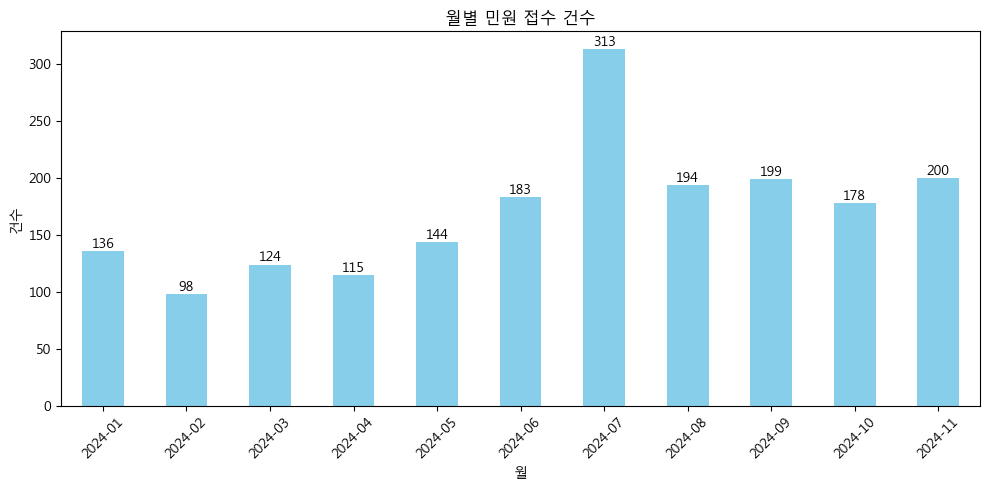

In [55]:
# 월별 시각화
plt.figure(figsize=(10, 5))
bars = month_counts.plot(kind='bar', color='skyblue')

# 각 막대 위에 수치 표시
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,  # x 위치
        height + 0.3,                       # y 위치 (막대 높이 + 여백)
        f'{int(height)}',                  # 텍스트 (정수로 변환)
        ha='center',                       # 수평 정렬
        va='bottom'                        # 수직 정렬
    )

plt.title('월별 민원 접수 건수')
plt.xlabel('월')
plt.ylabel('건수')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('monthly_complaints.png')
plt.show()

시간 순으로 확인

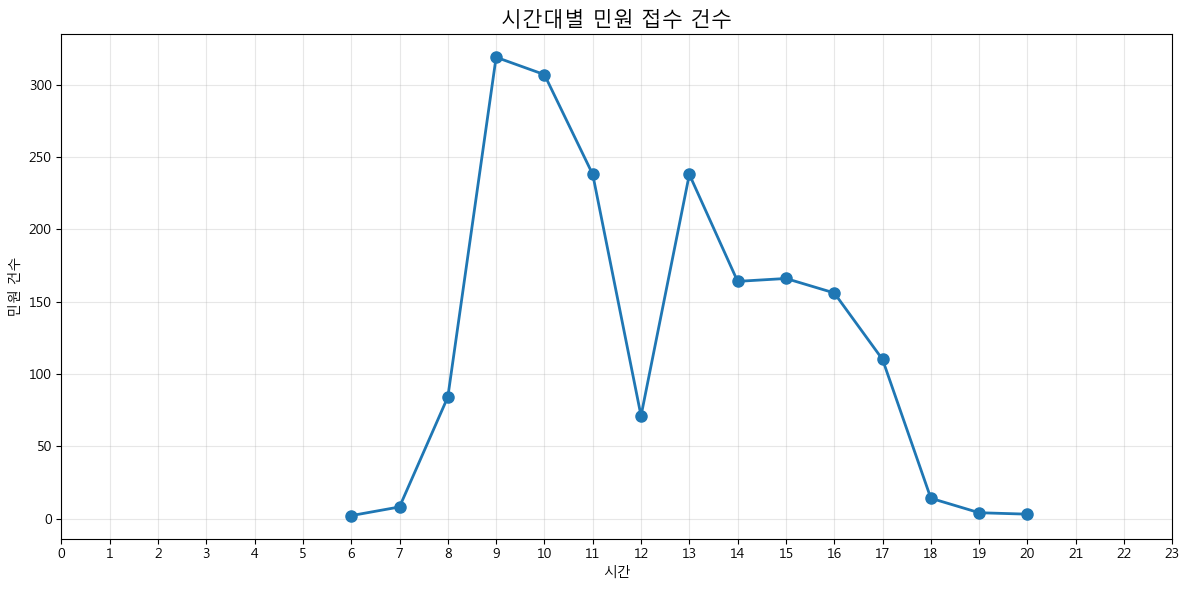

In [33]:
# 신청일시에서 시간대별 분석
df['시간'] = df['신청일시'].dt.hour
hour_counts = df['시간'].value_counts().sort_index()

# 시간대별 민원 건수 시각화 - 선 그래프
plt.figure(figsize=(12, 6))
plt.plot(hour_counts.index, hour_counts.values, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.title('시간대별 민원 접수 건수', fontproperties=font_prop, fontsize=15)
plt.xlabel('시간', fontproperties=font_prop)
plt.ylabel('민원 건수', fontproperties=font_prop)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('hourly_complaints_line.png', dpi=300)
plt.show()

고객관리사 분석

In [54]:
df['고객관리사'].value_counts()

고객관리사
이은순          575
김선희          128
정아름          119
김지윤           89
최은세(고객센터)     56
이현경(고객센터)     51
강연주(고객센터)     48
오윤미(고객센터)     47
권진이(고객센터)     47
장민희(고객센터)     44
김영기(고객센터)     43
성용범           43
김지혜(고객센터)     42
박수희(고객센터)     42
장유진(고객센터)     41
김영해(고객센터)     37
김주현(고객센터)     37
추현희(고객센터)     34
김도형           33
이민량(고객센터)     33
서나래(고객센터)     31
강재구           29
노미선(고객센터)     27
김은혜(고객센터)     23
박충우(고객센터)     21
한희열(고객센터)     21
이영미(고객센터)     20
이미선(고객센터)     20
박윤희           18
이보미(고객센터)     15
이영우           12
우미숙           11
김응도           11
송은경(고객센터)      9
권혁             8
윤지운            5
홍성원            5
김병훈            3
김태민            3
최혁             2
임민영(고객센터)      1
이선옥            1
Name: count, dtype: int64

In [56]:
df['고객관리사'].nunique()

42

위치 데이터 분석

In [ ]:
df['위치'].nunique()

29

In [52]:
df['위치'].value_counts()

위치
연무읍        287
강경읍        197
벌곡면        169
연산면        134
취암동        133
부적면        114
양촌면        101
은진면         93
가야곡면        89
내동          77
성동면         77
광석면         61
부창동         54
노성면         53
대교동         52
반월동         35
채운면         34
상월면         32
지산동         24
화지동         23
강산동         14
덕지동         13
등화동          9
관촉동          4
송당리          2
동흥리          1
신양리          1
안심리          1
적면 신교리       1
Name: count, dtype: int64

In [57]:
df['위치'].nunique()

29

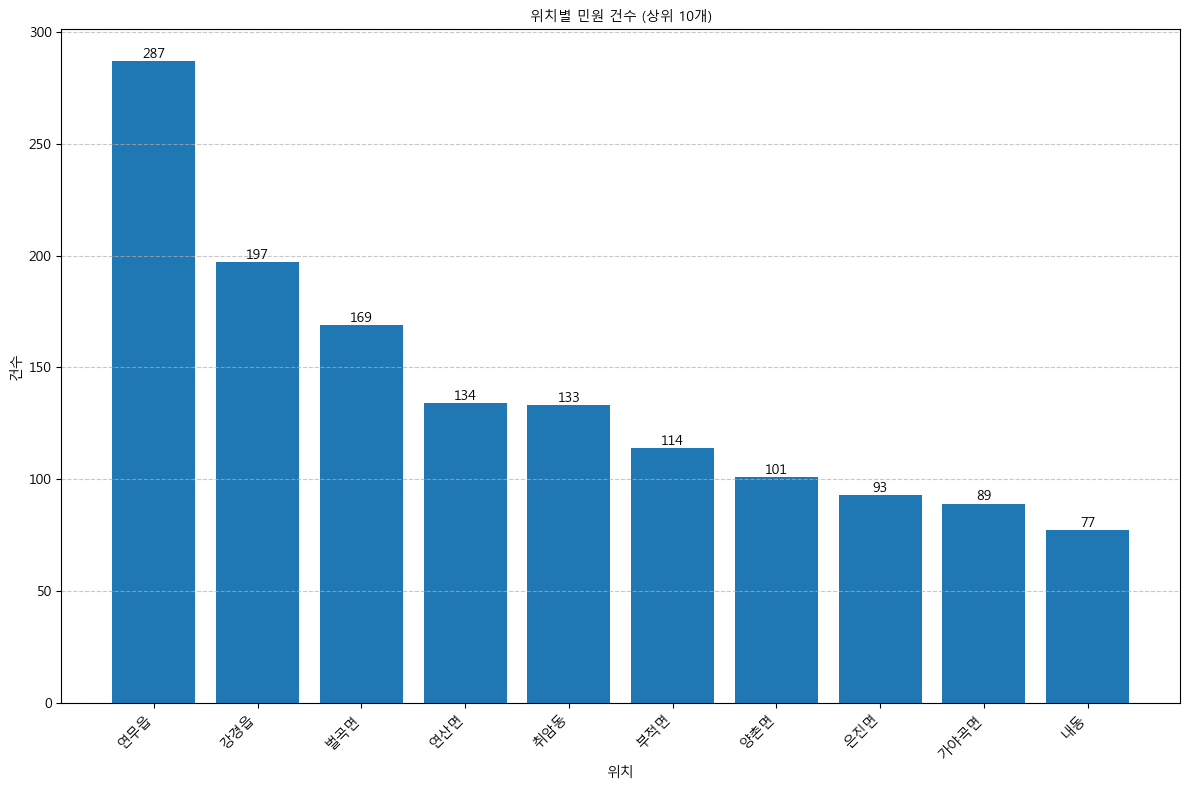

In [13]:
# 위치 데이터 빈도 계산
location_counts = df['위치'].value_counts()

# 상위 10개만 선택 (데이터가 많을 경우)
top_locations = location_counts.head(10)

# 시각화
plt.figure(figsize=(12, 8))
bars = plt.bar(top_locations.index, top_locations.values)

# 막대 위에 숫자 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}',
             ha='center', va='bottom')

plt.title('위치별 민원 건수 (상위 10개)', fontproperties=font_prop)
plt.xlabel('위치', fontproperties=font_prop)
plt.ylabel('건수', fontproperties=font_prop)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.savefig('location_counts.png')
plt.show()

지도 시각화

In [34]:
# pip install folium requests tqdm

   ---------------------------------------- 0.0/110.9 kB ? eta -:--:--
   ---------------------------------------- 110.9/110.9 kB 6.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/88.4 kB ? eta -:--:--
   ---------------------------------------- 88.4/88.4 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [36]:
# pip install geopandas

   ---------------------------------------- 0.0/323.6 kB ? eta -:--:--
   ---------------------------------------  317.4/323.6 kB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 323.6/323.6 kB 6.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
    --------------------------------------- 0.4/16.2 MB 8.0 MB/s eta 0:00:02
   -- ------------------------------------- 1.1/16.2 MB 11.6 MB/s eta 0:00:02
   ---- ----------------------------------- 2.0/16.2 MB 14.0 MB/s eta 0:00:02
   ------- -------------------------------- 3.1/16.2 MB 18.0 MB/s eta 0:00:01
   ---------- ----------------------------- 4.3/16.2 MB 19.6 MB/s eta 0:00:01
   -------------- ------------------------- 5.7/16.2 MB 21.6 MB/s eta 0:00:01
   ----------------- ---------------------- 7.3/16.2 MB 23.3 MB/s eta 0:00:01
   ---------------------- ----------------- 8.9/16.2 MB 24.8 MB/s eta 0:00:01
   --------------------------- ------------ 11.0/16.2 MB 31.2 MB/s eta 0:00:

CP949 인코딩으로 파일을 성공적으로 로드했습니다.

=== SHP 파일 기본 정보 ===
데이터 형태: (5065, 4)
컬럼 목록: ['EMD_CD', 'EMD_ENG_NM', 'EMD_KOR_NM', 'geometry']

=== 처음 5개 행 ===
     EMD_CD       EMD_ENG_NM EMD_KOR_NM  \
0  11110101    Cheongun-dong        청운동   
1  11110102      Singyo-dong        신교동   
2  11110103   Gungjeong-dong        궁정동   
3  11110104       Hyoja-dong        효자동   
4  11110105  Changseong-dong        창성동   

                                            geometry  
0  POLYGON ((953700.022 1954605.065, 953693.871 1...  
1  POLYGON ((953233.465 1953996.984, 953235.183 1...  
2  POLYGON ((953560.228 1954257.466, 953561.19 19...  
3  POLYGON ((953519.843 1953890.785, 953518.489 1...  
4  POLYGON ((953516.123 1953734.362, 953516.526 1...  


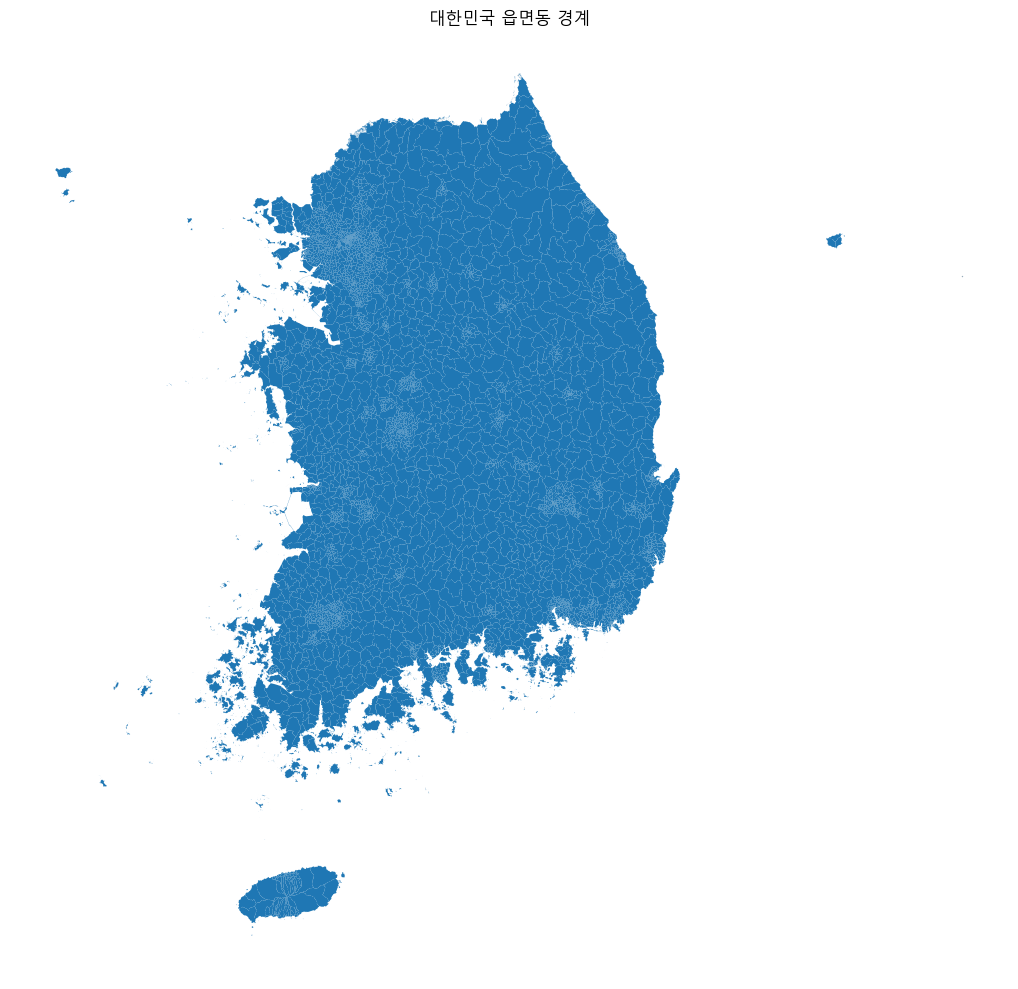

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# SHP 파일 로드 (다른 인코딩 시도)
shp_file_path = r'C:\Users\rladn\Desktop\과제\emd_20230729\emd.shp'

# cp949 인코딩으로 시도
try:
    gdf = gpd.read_file(shp_file_path, encoding='cp949')
    print("CP949 인코딩으로 파일을 성공적으로 로드했습니다.")
except Exception as e1:
    print(f"CP949 인코딩 시도 실패: {e1}")
    try:
        # euc-kr 인코딩으로 시도
        gdf = gpd.read_file(shp_file_path, encoding='euc-kr')
        print("EUC-KR 인코딩으로 파일을 성공적으로 로드했습니다.")
    except Exception as e2:
        print(f"EUC-KR 인코딩 시도 실패: {e2}")
        try:
            # 인코딩 지정 없이 시도
            gdf = gpd.read_file(shp_file_path)
            print("기본 인코딩으로 파일을 성공적으로 로드했습니다.")
        except Exception as e3:
            print(f"기본 인코딩 시도 실패: {e3}")
            print("파일을 로드할 수 없습니다. 다른 방법을 시도해보세요.")
            raise

# 데이터 기본 정보 확인
if 'gdf' in locals():
    print("\n=== SHP 파일 기본 정보 ===")
    print(f"데이터 형태: {gdf.shape}")
    print(f"컬럼 목록: {gdf.columns.tolist()}")
    print("\n=== 처음 5개 행 ===")
    print(gdf.head())

    # 간단한 지도 시각화
    fig, ax = plt.subplots(figsize=(12, 10))
    gdf.plot(ax=ax)
    plt.title('대한민국 읍면동 경계')
    plt.axis('off')
    plt.tight_layout()
    # plt.savefig('korea_emd_map.png', dpi=300)
    plt.show()

In [43]:
gdf.head()

,EMD_CD,EMD_ENG_NM,EMD_KOR_NM,geometry
0,11110101,Cheongun-dong,청운동,"POLYGON ((953700.022 1954605.065, 953693.871 1..."
1,11110102,Singyo-dong,신교동,"POLYGON ((953233.465 1953996.984, 953235.183 1..."
2,11110103,Gungjeong-dong,궁정동,"POLYGON ((953560.228 1954257.466, 953561.19 19..."
3,11110104,Hyoja-dong,효자동,"POLYGON ((953519.843 1953890.785, 953518.489 1..."
4,11110105,Changseong-dong,창성동,"POLYGON ((953516.123 1953734.362, 953516.526 1..."


'4423'으로 시작하는 행정동 수: 24

=== 필터링된 행정동 목록 ===
        EMD_CD EMD_KOR_NM
2661  44230101        화지동
2662  44230102        반월동
2663  44230103        대교동
2664  44230104        부창동
2665  44230105        취암동
2666  44230106        등화동
2667  44230107        지산동
2668  44230108        덕지동
2669  44230109         내동
2670  44230110        강산동


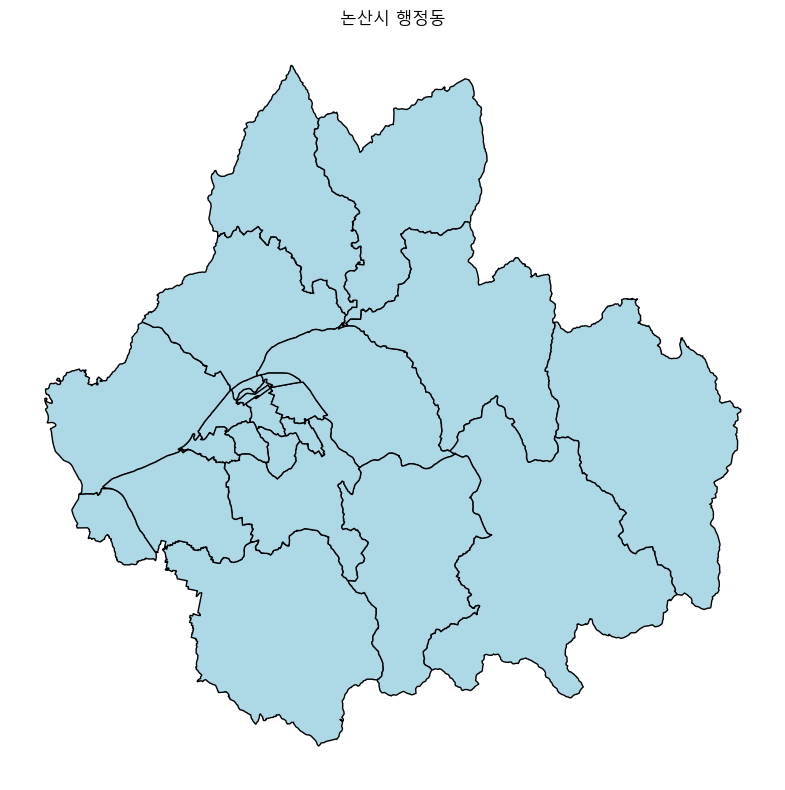

In [45]:
# EMD_CD 컬럼에서 앞 4자리가 '4423'인 행정동 필터링
filtered_gdf = gdf[gdf['EMD_CD'].str.startswith('4423')]

# 또는 문자열 슬라이싱 사용
# filtered_gdf = gdf[gdf['EMD_CD'].str[:4] == '4423']

# 결과 확인
print(f"'4423'으로 시작하는 행정동 수: {len(filtered_gdf)}")
print("\n=== 필터링된 행정동 목록 ===")
print(filtered_gdf[['EMD_CD', 'EMD_KOR_NM']].head(10))  # 상위 10개만 출력

# 필터링된 지도 시각화
fig, ax = plt.subplots(figsize=(12, 8))
filtered_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue')
plt.title("논산시 행정동")
plt.axis('off')
plt.tight_layout()
# plt.savefig('filtered_emd_map.png', dpi=300)
plt.show()

In [53]:
filtered_gdf.info()
filtered_gdf.EMD_KOR_NM.value_counts()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 24 entries, 2661 to 2684
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   EMD_CD      24 non-null     object  
 1   EMD_ENG_NM  24 non-null     object  
 2   EMD_KOR_NM  24 non-null     object  
 3   geometry    24 non-null     geometry
dtypes: geometry(1), object(3)
memory usage: 960.0+ bytes


EMD_KOR_NM
화지동     1
반월동     1
은진면     1
가야곡면    1
양촌면     1
벌곡면     1
연산면     1
부적면     1
상월면     1
노성면     1
광석면     1
성동면     1
연무읍     1
강경읍     1
관촉동     1
강산동     1
내동      1
덕지동     1
지산동     1
등화동     1
취암동     1
부창동     1
대교동     1
채운면     1
Name: count, dtype: int64

민원에서 나오는 위치값 개수 = 29
읍면동 shp파일 위치값 개수 = 24
* 개수 다른 이유 -> 리 추가 필요
 - 리 shp파일 다운로드 후 기존 읍면동과 논산시 법정동 코드 4423적요 후 concat()사용
 - 데이터 합친 후 변경사항 확인
 - 이후 민원 개수를 지도에 수치화

대분류 분석

In [14]:
df['대분류'].value_counts()

대분류
급수      685
계량기     633
누수      393
수질       69
급수시설     64
요금       23
기타민원      6
수용가       6
검침        4
고지        2
Name: count, dtype: int64

민원 내용 데이터 분석
 - 텍스트 데이터 전처리

In [15]:
# pip install konlpy

In [16]:
import pandas as pd
import numpy as np
import re
from konlpy.tag import Okt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한국어 형태소 분석기 초기화
okt = Okt()

# 텍스트 전처리 함수
def preprocess_text(text):
    if pd.isna(text):  # 결측값 처리
        return ""
    
    # 문자열로 변환
    text = str(text)
    
    # 특수문자 및 숫자 제거
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'[0-9]', ' ', text)
    
    # 여러 개의 공백을 하나로 대체
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [17]:
# 단어 추출 함수 (간단한 공백 기반 토큰화)
def extract_words(text, min_len=2):
    if not text:
        return []
    
    # 공백으로 단어 분리
    words = text.split()
    
    # 불용어 목록
    stopwords = ['있는', '없는', '되어', '하는', '이런', '저런', '그런', '및', '등', '이고', '입니다', '있습니다', 
                 '합니다', '이', '그', '저', '것', '수', '등', '이다', '한', '에', '에서', '로', '으로', '을', '를',
                 '이런', '저런', '하는', '해서', '한다', '된다', '에서', '있다', '없다', 
                 '요청', '확인요청', '문자이관', '하심', '문자', '담당자', 'CS팀', '있음', '확인', '빠른', '갑자기',
                 '방문', '문자전송함']
    
    # 길이가 min_len 이상이고 불용어가 아닌 단어만 선택
    words = [word for word in words if len(word) >= min_len and word not in stopwords]
    
    return words

In [18]:
# 민원내용 컬럼의 데이터 전처리
df['민원내용_전처리'] = df['민원내용'].apply(preprocess_text)

# 전처리된 내용에서 단어 추출
df['민원내용_단어'] = df['민원내용_전처리'].apply(extract_words)

In [19]:
# 결과 확인
print("=== 전처리 결과 샘플 ===")
for i in range(5):  # 5개의 샘플만 표시
    if i < len(df):
        original = df['민원내용'].iloc[i]
        preprocessed = df['민원내용_전처리'].iloc[i]
        words = df['민원내용_단어'].iloc[i]
        
        print(f"원본: {original}")
        print(f"전처리: {preprocessed}")
        print(f"추출 단어: {words}")
        print("-" * 80)

=== 전처리 결과 샘플 ===
원본: 수용가 옆집수도설치시 고객님댁들어오는 인입관로에서 연결해서 설치했는데 인입전에서 누수가 되는지 지반이 계속 침하가 된다고 확인요청
옆집은 이사을 가서 수도사용을 하지 않는다고함-광석면담당업무폰문자이관
전처리: 수용가 옆집수도설치시 고객님댁들어오는 인입관로에서 연결해서 설치했는데 인입전에서 누수가 되는지 지반이 계속 침하가 된다고 확인요청 옆집은 이사을 가서 수도사용을 하지 않는다고함 광석면담당업무폰문자이관
추출 단어: ['수용가', '옆집수도설치시', '고객님댁들어오는', '인입관로에서', '연결해서', '설치했는데', '인입전에서', '누수가', '되는지', '지반이', '계속', '침하가', '된다고', '옆집은', '이사을', '가서', '수도사용을', '하지', '않는다고함', '광석면담당업무폰문자이관']
--------------------------------------------------------------------------------
원본: 밸브가 안잠긴다고함 
남서부권 문자 
전처리: 밸브가 안잠긴다고함 남서부권 문자
추출 단어: ['밸브가', '안잠긴다고함', '남서부권']
--------------------------------------------------------------------------------
원본: 상수관노출
전처리: 상수관노출
추출 단어: ['상수관노출']
--------------------------------------------------------------------------------
원본: 계량기고장
전처리: 계량기고장
추출 단어: ['계량기고장']
--------------------------------------------------------------------------------
원본: 어제 단수된 이후 물은 나오나 수압이 너무 약하다고 하시며   아직  공사 완료가 되지 않은건지  완료가 되었는데 수압이 약한건지 확인 요청 /
전처리: 어제

In [20]:
# 단어 빈도 계산
all_words = []
for words in df['민원내용_단어']:
    all_words.extend(words)

# 단어 빈도 계산
word_count = Counter(all_words)

# 상위 20개 단어 출력
print("\n=== 민원내용에서 가장 많이 등장하는 단어 (상위 20개) ===")
for word, count in word_count.most_common(20):
    print(f"{word}: {count}회")

# 전체 데이터에서 토큰화된 단어 수 확인
print(f"\n전체 단어 수: {len(all_words)}개")
print(f"중복 제거 후 고유 단어 수: {len(word_count)}개")


=== 민원내용에서 가장 많이 등장하는 단어 (상위 20개) ===
계량기: 452회
물이: 382회
북동부권: 125회
수압이: 114회
계량기고장: 97회
불출수: 92회
상하수도과: 91회
밸브: 89회
남서부권: 82회
누수: 80회
이관: 58회
도로누수: 52회
누수가: 51회
지침부동: 51회
밸브고장: 50회
있다고: 49회
고장: 48회
많이: 47회
계량기가: 47회
너무: 45회

전체 단어 수: 13455개
중복 제거 후 고유 단어 수: 5097개


처음 결과 확인

=== 민원내용에서 가장 많이 등장하는 단어 (상위 20개) ===
계량기: 452회
물이: 382회
요청: 263회
확인요청: 198회
확인: 186회
문자이관: 183회
북동부권: 125회
하심: 122회
수압이: 114회
문자: 102회
계량기고장: 97회
불출수: 92회
상하수도과: 91회
밸브: 89회
담당자: 87회
빠른: 85회
CS팀: 83회
남서부권: 82회
누수: 80회
있음: 67회

요청, 확인요청, 문자이관, 하심, 문자, 담당자, CS팀, 있음 -> 단어 확인 -> 불용어 추가

민원 내용 데이터 분석
 - 워드클라우드(Word Cloud)

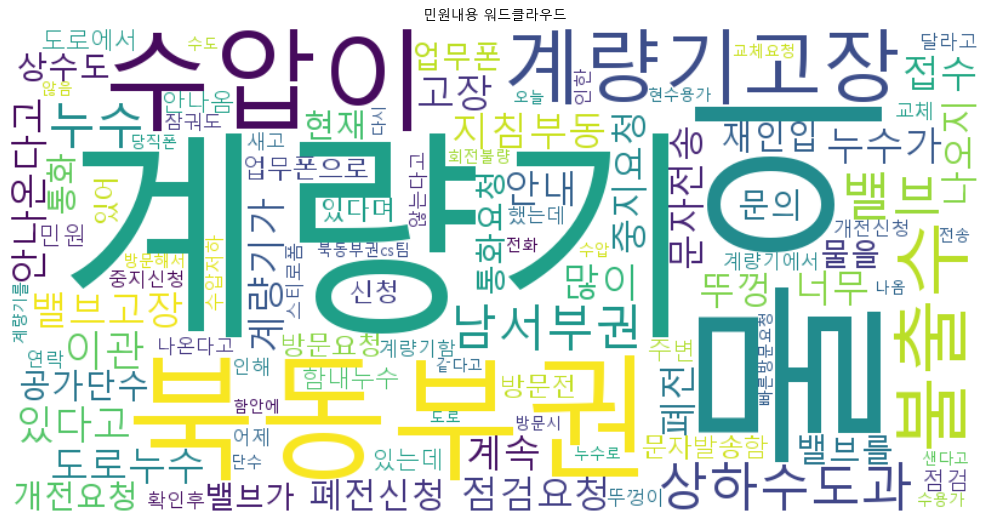

In [21]:
from wordcloud import WordCloud

# 한글 폰트 경로 설정
system_name = platform.system()
if system_name == 'Windows':
    font_path = r'C:\Windows\Fonts\malgun.ttf'  # 윈도우의 맑은 고딕 폰트
elif system_name == 'Darwin':  # macOS
    font_path = '/System/Library/Fonts/AppleGothic.ttf'
else:  # Linux 등
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 워드클라우드 생성 (한글 폰트 지정)
wordcloud = WordCloud(
    font_path=font_path,  # 한글 폰트 경로 지정
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate_from_frequencies(word_count)

# 시각화
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('민원내용 워드클라우드', fontproperties=fm.FontProperties(fname=font_path))
plt.tight_layout()
plt.show()

민원 내용 데이터 분석
 - 네트워크 그래프(Network Graph)

In [22]:
# pip install networkx

In [23]:
# pip install scipy

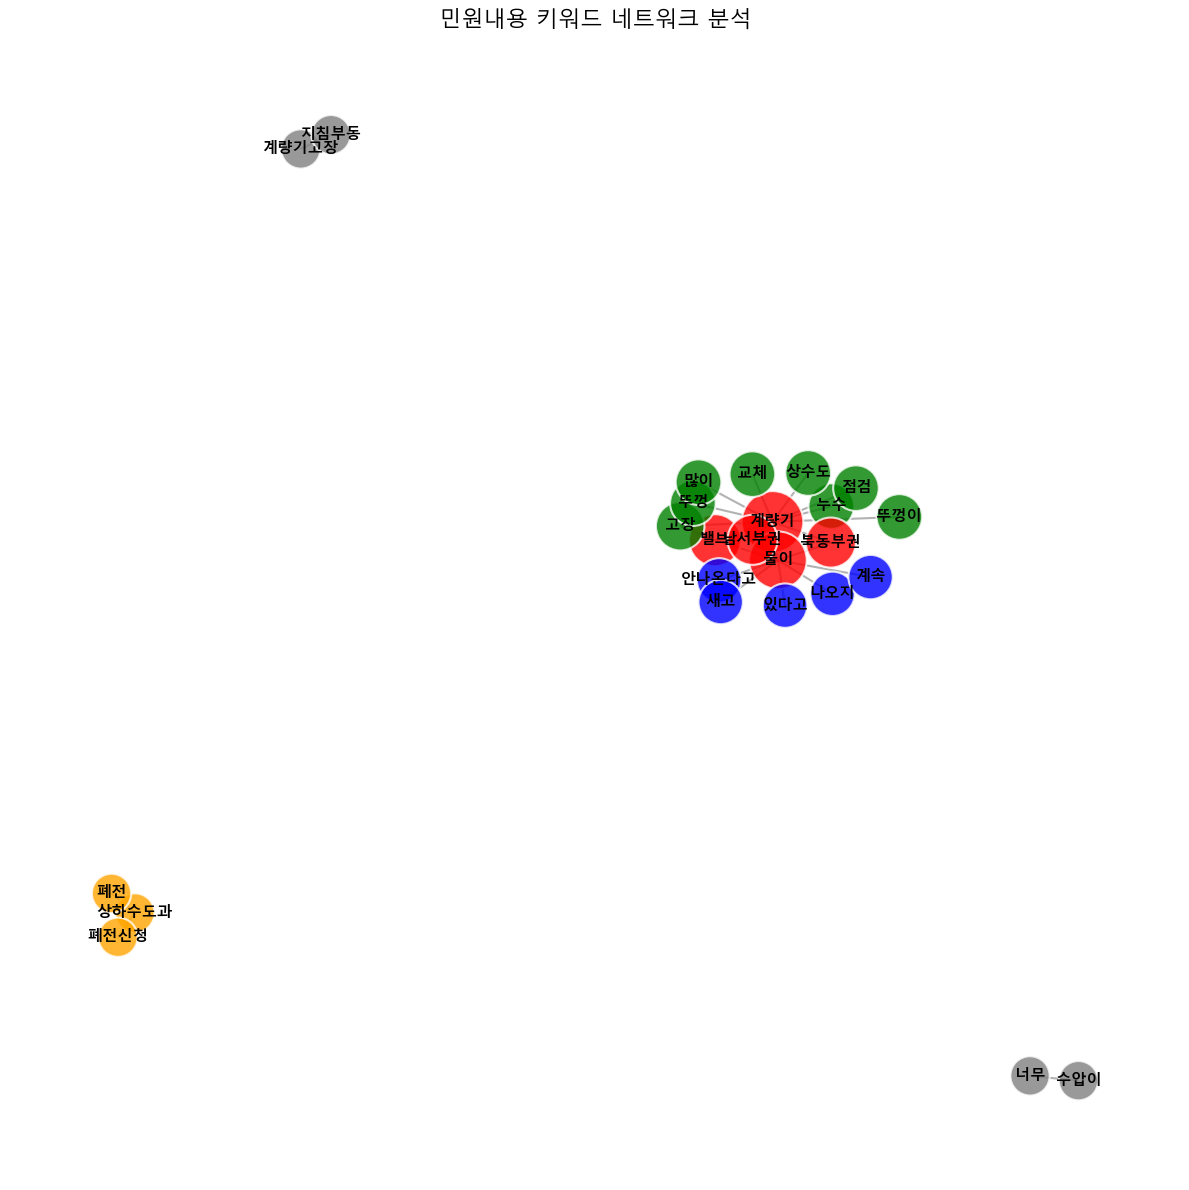

노드(단어) 수: 25
엣지(연결) 수: 25

가장 중요한 단어 TOP 5:
계량기: 중심성 0.5812
물이: 중심성 0.4593
밸브: 중심성 0.2984
북동부권: 중심성 0.2483
남서부권: 중심성 0.2483


In [24]:
import networkx as nx
from collections import defaultdict
import matplotlib.font_manager as fm

# 함께 등장하는 단어 쌍 찾기
word_pairs = defaultdict(int)
for words in df['민원내용_단어']:
    for i, word1 in enumerate(words):
        for word2 in words[i+1:]:
            if word1 != word2:
                word_pair = tuple(sorted([word1, word2]))
                word_pairs[word_pair] += 1

# 상위 25개 연관 단어쌍만 선택 (원하는 대로 조정 가능)
top_pairs = sorted(word_pairs.items(), key=lambda x: x[1], reverse=True)[:25]

# 최소 빈도 값 설정
min_weight = 2
filtered_pairs = [(pair, weight) for pair, weight in top_pairs if weight >= min_weight]

# 네트워크 그래프 생성
G = nx.Graph()
for (word1, word2), weight in filtered_pairs:
    G.add_edge(word1, word2, weight=weight)

# 노드 중요도 계산 (중심성 활용)
centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)

# 색상 그룹 분류 (중심성 기반)
# 중심성 값을 5개 구간으로 나누어 색상 할당
centrality_values = list(centrality.values())
color_groups = {}

# 색상 그룹 정의 (5개 구간)
for node in G.nodes():
    if centrality[node] >= np.percentile(centrality_values, 80):
        color_groups[node] = 'red'  # 상위 20% - 빨강
    elif centrality[node] >= np.percentile(centrality_values, 60):
        color_groups[node] = 'green'  # 상위 20-40% - 초록
    elif centrality[node] >= np.percentile(centrality_values, 40):
        color_groups[node] = 'blue'  # 상위 40-60% - 파랑
    elif centrality[node] >= np.percentile(centrality_values, 20):
        color_groups[node] = 'orange'  # 상위 60-80% - 주황
    else:
        color_groups[node] = 'gray'  # 하위 20% - 회색

# 노드 색상 배열 생성
node_colors = [color_groups[node] for node in G.nodes()]

# 노드 크기 (중심성에 비례)
node_size = [centrality[node] * 2000 + 800 for node in G.nodes()]

# 레이아웃 - Fruchterman-Reingold 알고리즘 사용 (2번째 이미지와 유사)
pos = nx.fruchterman_reingold_layout(G, k=0.3, iterations=50, seed=42)

# 그래프 시각화
plt.figure(figsize=(12, 12), facecolor='white')

# 엣지 그리기 (투명도 낮게 하여 선명하게)
nx.draw_networkx_edges(G, pos, 
                      width=1.5,           # 선 두께 고정
                      alpha=0.6,           # 투명도
                      edge_color='gray')   # 선 색상

# 노드 그리기
nx.draw_networkx_nodes(G, pos,
                      node_size=node_size,
                      node_color=node_colors,
                      alpha=0.8,
                      edgecolors='white',  # 노드 테두리 색상
                      linewidths=1.5)      # 노드 테두리 두께

# 라벨 그리기
nx.draw_networkx_labels(G, pos,
                      font_family=font_prop.get_name(),
                      font_size=11,
                      font_weight='bold',
                      font_color='black')

# 제목 및 설정
plt.title('민원내용 키워드 네트워크 분석', fontproperties=font_prop, fontsize=16)
plt.axis('off')
plt.tight_layout()
# plt.savefig('word_network_colorful.png', dpi=300, bbox_inches='tight')
plt.show()

# 네트워크 정보 출력
print(f"노드(단어) 수: {G.number_of_nodes()}")
print(f"엣지(연결) 수: {G.number_of_edges()}")
print("\n가장 중요한 단어 TOP 5:")
for word, cent in sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{word}: 중심성 {cent:.4f}")

- 네트워크 그래프에서 주요 그룹만 확인

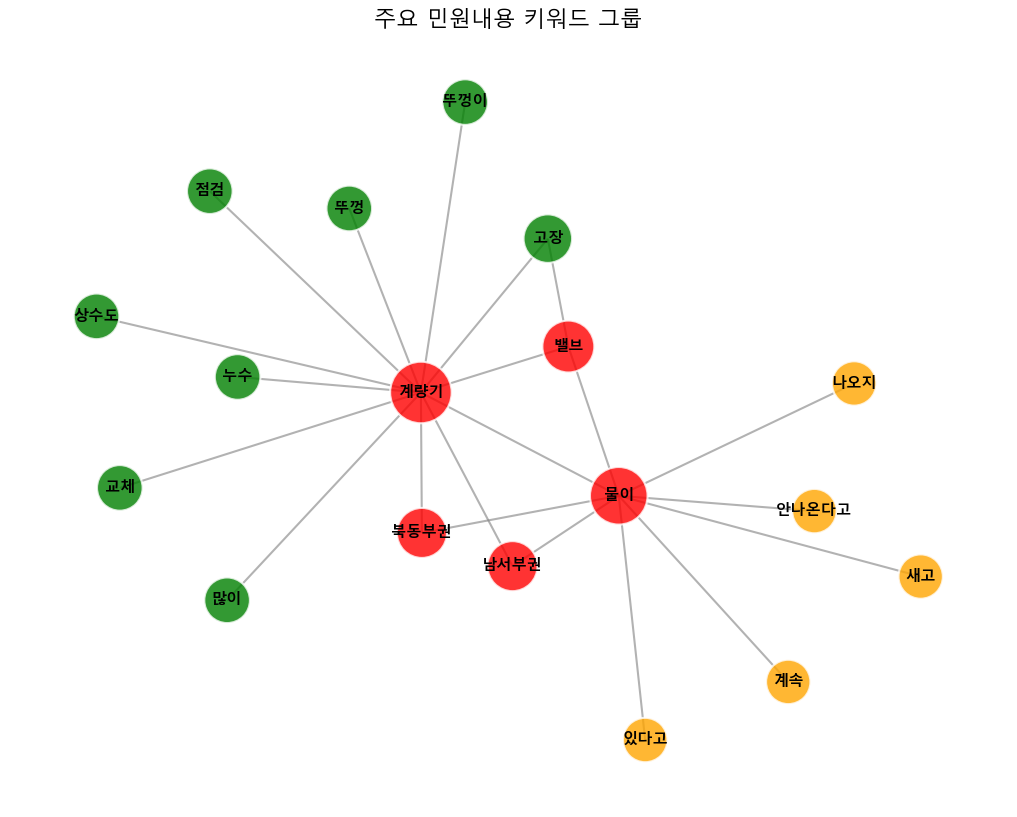

메인 그룹 노드(단어) 수: 18
메인 그룹 엣지(연결) 수: 21

메인 그룹 중요 단어 TOP 5:
계량기: 중심성 0.5812
물이: 중심성 0.4593
밸브: 중심성 0.2984
북동부권: 중심성 0.2483
남서부권: 중심성 0.2483


In [25]:
font_prop = fm.FontProperties(fname=font_path)
plt.rc('font', family=font_prop.get_name())
plt.rcParams['axes.unicode_minus'] = False

# 함께 등장하는 단어 쌍 찾기
word_pairs = defaultdict(int)
for words in df['민원내용_단어']:
    for i, word1 in enumerate(words):
        for word2 in words[i+1:]:
            if word1 != word2:
                word_pair = tuple(sorted([word1, word2]))
                word_pairs[word_pair] += 1

# 상위 25개 연관 단어쌍만 선택
top_pairs = sorted(word_pairs.items(), key=lambda x: x[1], reverse=True)[:25]

# 최소 빈도 값 설정
min_weight = 2
filtered_pairs = [(pair, weight) for pair, weight in top_pairs if weight >= min_weight]

# 네트워크 그래프 생성
G = nx.Graph()
for (word1, word2), weight in filtered_pairs:
    G.add_edge(word1, word2, weight=weight)

# 커뮤니티 탐지 - 연결 컴포넌트 찾기
components = list(nx.connected_components(G))
components.sort(key=len, reverse=True)

# 가장 큰 커뮤니티(메인 그룹) 추출
main_group = G.subgraph(components[0])

# 노드 중요도 계산
centrality = nx.eigenvector_centrality(main_group, max_iter=1000, tol=1e-06)

# 색상 그룹 분류
centrality_values = list(centrality.values())
color_groups = {}

for node in main_group.nodes():
    if centrality[node] >= np.percentile(centrality_values, 80):
        color_groups[node] = 'red'
    elif centrality[node] >= np.percentile(centrality_values, 60):
        color_groups[node] = 'green'
    elif centrality[node] >= np.percentile(centrality_values, 40):
        color_groups[node] = 'blue'
    elif centrality[node] >= np.percentile(centrality_values, 20):
        color_groups[node] = 'orange'
    else:
        color_groups[node] = 'gray'

# 노드 색상 배열 생성
node_colors = [color_groups[node] for node in main_group.nodes()]

# 노드 크기 (중심성에 비례)
node_size = [centrality[node] * 2000 + 800 for node in main_group.nodes()]

# 레이아웃 - 노드 간 거리 줄이기
pos = nx.fruchterman_reingold_layout(main_group, k=0.15, iterations=100, seed=42)

# 그래프 시각화
plt.figure(figsize=(10, 8), facecolor='white')

# 엣지 그리기
nx.draw_networkx_edges(main_group, pos, 
                      width=1.5,
                      alpha=0.6,
                      edge_color='gray')

# 노드 그리기
nx.draw_networkx_nodes(main_group, pos,
                      node_size=node_size,
                      node_color=node_colors,
                      alpha=0.8,
                      edgecolors='white',
                      linewidths=1.5)

# 라벨 그리기
nx.draw_networkx_labels(main_group, pos,
                      font_family=font_prop.get_name(),
                      font_size=11,
                      font_weight='bold',
                      font_color='black')

# 제목 및 설정
plt.title('주요 민원내용 키워드 그룹', fontproperties=font_prop, fontsize=16)
plt.axis('off')
plt.tight_layout(pad=0.1)

# plt.savefig('main_group_network.png', dpi=300, bbox_inches='tight')
plt.show()

# 그룹 정보 출력
print(f"메인 그룹 노드(단어) 수: {main_group.number_of_nodes()}")
print(f"메인 그룹 엣지(연결) 수: {main_group.number_of_edges()}")
print("\n메인 그룹 중요 단어 TOP 5:")
for word, cent in sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{word}: 중심성 {cent:.4f}")

민원 데이터 분석
 - 히트맵 분석(Heatmap)

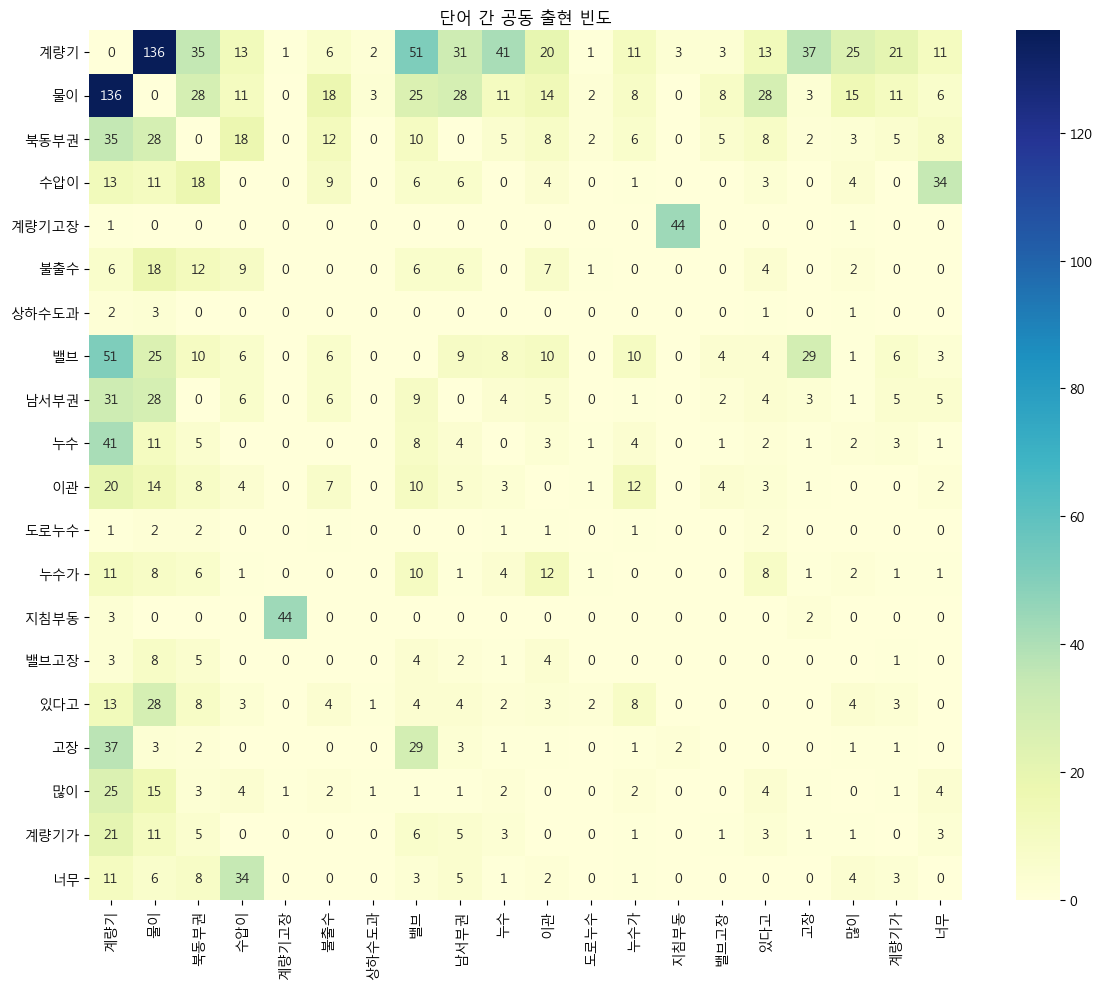

In [26]:
# 상위 20개 단어 추출
top_words = [word for word, _ in word_count.most_common(20)]

# 공동 출현 행렬 생성
co_occurrence = np.zeros((len(top_words), len(top_words)))
word_to_idx = {word: i for i, word in enumerate(top_words)}

for words in df['민원내용_단어']:
    for i, word1 in enumerate(words):
        if word1 in word_to_idx:
            for word2 in words:
                if word2 in word_to_idx and word1 != word2:
                    co_occurrence[word_to_idx[word1]][word_to_idx[word2]] += 1

# 히트맵 생성
plt.figure(figsize=(12, 10))
sns.heatmap(
    co_occurrence, 
    annot=True, 
    fmt=".0f", 
    xticklabels=top_words, 
    yticklabels=top_words,
    cmap="YlGnBu"
)
plt.title('단어 간 공동 출현 빈도')
plt.tight_layout()
plt.show()

민원 내용 데이터 분석
 - 토픽 모델링 시각화

In [27]:
# !conda uninstall scipy gensim -y
# !conda install scipy=1.10.1 -y
# !conda install -c conda-forge gensim=4.3.1 -y
# !conda install -c conda-forge pyldavis -y

In [28]:
# from gensim import corpora
# from gensim.models import LdaModel
# from gensim.models.coherencemodel import CoherenceModel
# import pyLDAvis.gensim_models
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
# import platform

# # 코퍼스 생성
# dictionary = corpora.Dictionary(df['민원내용_단어'])
# corpus = [dictionary.doc2bow(text) for text in df['민원내용_단어']]

# # 최적의 토픽 수 찾기 (선택 사항)
# def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
#     """
#     여러 토픽 수에 대한 일관성 점수를 계산
#     """
#     coherence_values = []
#     model_list = []
#     for num_topics in range(start, limit, step):
#         model = LdaModel(
#             corpus=corpus,
#             id2word=dictionary,
#             num_topics=num_topics,
#             passes=10,
#             alpha='auto',
#             per_word_topics=True
#         )
#         model_list.append(model)
        
#         coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
#         coherence_values.append(coherencemodel.get_coherence())
    
#     return model_list, coherence_values

# # 최적의 토픽 수 찾기 (2~10개 범위)
# model_list, coherence_values = compute_coherence_values(
#     dictionary=dictionary, 
#     corpus=corpus, 
#     texts=df['민원내용_단어'], 
#     start=2, 
#     limit=11, 
#     step=1
# )

# # 일관성 점수 시각화
# plt.figure(figsize=(12, 6))
# plt.plot(range(2, 11), coherence_values, 'o-')
# plt.xlabel('토픽 수', fontproperties=font_prop)
# plt.ylabel('일관성 점수', fontproperties=font_prop)
# plt.title('토픽 수에 따른 일관성 점수 변화', fontproperties=font_prop)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('topic_coherence_scores.png', dpi=300)
# plt.show()

# # 최적의 토픽 수 선택 (일관성 점수가 가장 높은 값)
# optimal_num_topics = 2 + coherence_values.index(max(coherence_values))
# print(f"최적의 토픽 수: {optimal_num_topics}")
# print(f"최고 일관성 점수: {max(coherence_values):.4f}")

# # 최적 토픽 수로 최종 LDA 모델 학습
# lda_model = LdaModel(
#     corpus=corpus,
#     id2word=dictionary,
#     num_topics=optimal_num_topics,
#     passes=10,
#     alpha='auto',
#     per_word_topics=True
# )

# # 토픽 출력
# print("\n토픽 추출 결과:")
# for idx, topic in lda_model.print_topics():
#     print(f"토픽 #{idx}: {topic}")

# # 각 문서별 주요 토픽 할당
# doc_topics = []
# for i, doc in enumerate(corpus):
#     topic_probs = lda_model.get_document_topics(doc)
#     # 확률이 가장 높은 토픽 선택
#     main_topic = sorted(topic_probs, key=lambda x: x[1], reverse=True)[0][0]
#     doc_topics.append(main_topic)

# # 토픽별 문서 수 시각화
# topic_counts = pd.Series(doc_topics).value_counts().sort_index()
# plt.figure(figsize=(10, 6))
# bars = plt.bar(
#     [f'토픽 {i}' for i in topic_counts.index], 
#     topic_counts.values,
#     color='skyblue'
# )

# # 막대 위에 숫자 표시
# for bar in bars:
#     height = bar.get_height()
#     plt.text(
#         bar.get_x() + bar.get_width()/2.,
#         height + 0.5,
#         f'{int(height)}',
#         ha='center',
#         va='bottom'
#     )

# plt.title('토픽별 민원 문서 수', fontproperties=font_prop)
# plt.xlabel('토픽', fontproperties=font_prop)
# plt.ylabel('문서 수', fontproperties=font_prop)
# plt.tight_layout()
# plt.savefig('topic_document_counts.png', dpi=300)
# plt.show()

# # pyLDAvis 시각화 생성 및 저장
# vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
# pyLDAvis.save_html(vis, 'lda_visualization.html')
# print("\n시각화 결과가 'lda_visualization.html' 파일로 저장되었습니다.")

# # 결과 요약
# print("\n=== 토픽 모델링 분석 요약 ===")
# print(f"분석된 문서 수: {len(df)}")
# print(f"추출된 토픽 수: {optimal_num_topics}")
# print(f"모델 일관성 점수: {max(coherence_values):.4f}")
# print("\n주요 토픽별 키워드:")
# for idx, topic in lda_model.print_topics():
#     print(f"토픽 #{idx}: {topic}")

토픽 모델링(LDA 분석)은 현재 sicpy 라이브러리와 gensim 라이브러리의 충돌로 인하여 오류가 발생중.
 - 해결책 :
 1. conda 환경 재설정 -> 오류
 2. 새로운 환경 설정 -> 오류
 3. scikit-learn 기반 접근 -> 오류

In [29]:
# # scikit-learn을 사용한 토픽 모델링
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.decomposition import LatentDirichletAllocation as LDA

# # 문서 텍스트 준비 (단어 리스트를 공백으로 구분된 문자열로 변환)
# doc_texts = [' '.join(words) for words in df['민원내용_단어']]

# # 단어 빈도 행렬 생성
# vectorizer = CountVectorizer(max_features=1000)
# word_count_matrix = vectorizer.fit_transform(doc_texts)

# # LDA 모델 학습
# n_topics = 5
# lda_model = LDA(n_components=n_topics, random_state=42)
# lda_model.fit(word_count_matrix)

# # 토픽별 상위 단어 출력
# feature_names = vectorizer.get_feature_names_out()
# for topic_idx, topic in enumerate(lda_model.components_):
#     top_words_idx = topic.argsort()[:-11:-1]  # 상위 10개 단어 인덱스
#     top_words = [feature_names[i] for i in top_words_idx]
#     print(f"토픽 #{topic_idx}: {' '.join(top_words)}")

민원 내용 데이터 분석
- 감성 분석(긍정/부정/중립)

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import urllib.request
import matplotlib.font_manager as fm
import platform

In [31]:
# # KNU 감성사전 다운로드 및 로드
# def load_knu_sentiment_lexicon():
#     print("KNU 감성사전 다운로드 중...")
    
#     # SentiWord_info.json 파일 다운로드
#     json_url = "https://raw.githubusercontent.com/park1200656/KnuSentiLex/master/data/SentiWord_info.json"
#     json_file = "SentiWord_info.json"
    
#     try:
#         urllib.request.urlretrieve(json_url, json_file)
#         print(f"감성사전 파일 다운로드 완료: {json_file}")
#     except Exception as e:
#         print(f"다운로드 중 오류 발생: {e}")
#         return None
    
#     # JSON 파일 로드
#     try:
#         with open(json_file, 'r', encoding='utf-8') as f:
#             sentiment_dict = json.load(f)
#         print(f"감성사전 로드 완료: {len(sentiment_dict)}개 단어")
#         return sentiment_dict
#     except Exception as e:
#         print(f"파일 로드 중 오류 발생: {e}")
#         return None


In [32]:
# KNU 감성사전 기반 감성 분석 함수
def analyze_sentiment_with_knu(df):
    # KNU 감성사전 로드
    sentiment_dict = load_knu_sentiment_lexicon()
    
    if sentiment_dict is None:
        print("감성사전 로드 실패. 분석을 진행할 수 없습니다.")
        return df
    
    print("\n민원 내용 감성 분석 중...")
    
    # 감성 분석 결과 저장
    sentiment_scores = []
    sentiment_categories = []
    sentiment_words = []
    
    # 각 민원 문서별 감성 분석
    for i, words in enumerate(df['민원내용_단어']):
        if not isinstance(words, list) or len(words) == 0:
            sentiment_scores.append(0)
            sentiment_categories.append('neutral')
            sentiment_words.append([])
            continue
        
        pos_score = 0
        neg_score = 0
        found_words = []
        
        # 각 단어별 감성 점수 계산
        for word in words:
            if word in sentiment_dict:
                polarity = sentiment_dict[word]["polarity"]
                
                if polarity == "POS":
                    pos_score += 1
                    found_words.append((word, "긍정"))
                elif polarity == "NEG":
                    neg_score += 1
                    found_words.append((word, "부정"))
        
        # 종합 감성 점수 계산
        total_score = pos_score - neg_score
        
        # 감성 범주 결정
        if total_score > 0:
            sentiment = 'positive'
        elif total_score < 0:
            sentiment = 'negative'
        else:
            sentiment = 'neutral'
        
        sentiment_scores.append(total_score)
        sentiment_categories.append(sentiment)
        sentiment_words.append(found_words)
    
    # 결과 데이터프레임에 추가
    df['감성점수_KNU'] = sentiment_scores
    df['감성범주_KNU'] = sentiment_categories
    df['감성단어_KNU'] = sentiment_words
    
    # 감성 분포 확인
    sentiment_counts = df['감성범주_KNU'].value_counts()
    print("\n=== KNU 감성사전 기반 감성 분석 결과 ===")
    print(sentiment_counts)
    
    # 결과 시각화
    plt.figure(figsize=(10, 6))
    colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
    sentiment_order = ['positive', 'neutral', 'negative']
    counts = [sentiment_counts.get(cat, 0) for cat in sentiment_order]
    
    bars = plt.bar(
        sentiment_order, 
        counts,
        color=[colors[cat] for cat in sentiment_order]
    )
    
    # 막대 위에 숫자 표시
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height + 0.5,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )
    
    plt.title('KNU 감성사전 기반 민원 감성 분석 결과', fontproperties=font_prop)
    plt.ylabel('민원 건수', fontproperties=font_prop)
    plt.tight_layout()
    plt.savefig('knu_sentiment_analysis.png', dpi=300)
    plt.show()
    
    # 분포 비율 출력
    total = sum(counts)
    print("\n감성 범주 비율:")
    for cat, count in zip(sentiment_order, counts):
        percentage = (count / total) * 100
        print(f"{cat}: {percentage:.1f}%")
    
    # 감성별 주요 키워드 분석
    print("\n=== 감성별 주요 키워드 ===")
    from collections import Counter
    
    for category in sentiment_order:
        # 해당 감성 범주에 속한 문서들의 감성 단어 수집
        category_words = []
        for i, sentiment in enumerate(df['감성범주_KNU']):
            if sentiment == category and isinstance(df['감성단어_KNU'].iloc[i], list):
                for word, _ in df['감성단어_KNU'].iloc[i]:
                    category_words.append(word)
        
        if category_words:
            # 단어 빈도 계산
            word_counts = Counter(category_words)
            
            # 상위 10개 단어 출력
            top_words = word_counts.most_common(10)
            print(f"\n{category.capitalize()} 감성의 주요 키워드:")
            for word, count in top_words:
                print(f"  - {word}: {count}회")
            
            # 상위 단어 시각화
            if top_words:
                plt.figure(figsize=(10, 6))
                words, counts = zip(*top_words)
                plt.barh(words, counts, color=colors[category])
                plt.title(f'{category.capitalize()} 감성 주요 키워드', fontproperties=font_prop)
                plt.xlabel('빈도', fontproperties=font_prop)
                plt.tight_layout()
                plt.savefig(f'knu_{category}_keywords.png', dpi=300)
                plt.show()
    
    # 감성별 예시 민원 출력
    print("\n=== 감성별 민원 예시 ===")
    for category in sentiment_order:
        category_docs = df[df['감성범주_KNU'] == category]
        
        print(f"\n{category.capitalize()} 민원 예시:")
        for i, (_, row) in enumerate(category_docs.head(2).iterrows(), 1):
            if isinstance(row['민원내용'], str):
                preview = row['민원내용'][:100] + ('...' if len(row['민원내용']) > 100 else '')
                sentiment_words_str = ', '.join([f"{word}({polarity})" for word, polarity in row['감성단어_KNU']]) if isinstance(row['감성단어_KNU'], list) else ""
                
                print(f"  {i}. {preview}")
                print(f"     감성 단어: {sentiment_words_str}")
                print(f"     감성 점수: {row['감성점수_KNU']}")
    
    return df

# 데이터프레임에 대해 KNU 감성사전 기반 감성 분석 실행
df_with_knu_sentiment = analyze_sentiment_with_knu(df)

NameError: name 'load_knu_sentiment_lexicon' is not defined

KNU 사전을 이용한 감성 분석 결과 전부 중립이 나오는 일 발생.

자체 감성 분석 모델을 만들어 제작해야하나?